# AlexNet and DHVT on the Same Dataset

## Objective

The goal of this notebook is to compare a classical convolutional neural network, AlexNet, with a modified transformer-based model, DHVT, on the same dataset. Both models use the same dataset setting, the same validation data, and the same custom images for inference.

## Introduction

This notebook follows a complete image classification workflow. I first prepare the dataset, then train AlexNet, then train DHVT from scratch, save the best models, reload them, and finally compare their predictions on the same custom images.

The comparison is more meaningful because both models are trained and evaluated under the same data conditions.

## Why Compare AlexNet and DHVT

AlexNet is a classical CNN that uses convolution and pooling to extract local features. DHVT is a transformer-style model designed for small datasets. It combines token-based processing with inductive bias introduced by convolutional patch embedding and dynamic feed-forward design.

This comparison is useful because it contrasts a classical CNN with a transformer-style architecture trained from scratch on the same task.

## Dataset Description

This notebook supports the following dataset choices:
- `cifar10`
- `cifar100`
- `custom_folder`

The same dataset choice is shared by AlexNet and DHVT.

## 1. Import the libraries

In [1]:
import csv
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
from PIL import Image
from torch.optim import lr_scheduler
from torchvision import datasets


## 2. Choose the runtime

In [20]:
runtime_mode = 'colab'  # 'local' or 'colab'

In [21]:
if runtime_mode == 'colab':
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    project_root = Path('/content/drive/MyDrive/classification-deep-learning-project')
    data_dir = Path('/content/data')
else:
    project_root = Path.cwd()
    data_dir = project_root / 'data'

model_dir = project_root / 'models'
prediction_dir = project_root / 'predictions'
test_images_dir = project_root / 'test_images'
custom_dataset_dir = project_root / 'custom_dataset'
report_figure_dir = project_root / 'report' / 'figures'

for folder in [data_dir, model_dir, prediction_dir, test_images_dir, custom_dataset_dir, report_figure_dir]:
    folder.mkdir(parents=True, exist_ok=True)

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Runtime mode:', runtime_mode)
print('Device:', device)
print('Seed:', seed)
print('cuDNN deterministic:', torch.backends.cudnn.deterministic)
print('cuDNN benchmark:', torch.backends.cudnn.benchmark)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Runtime mode: colab
Device: cuda
Seed: 42
cuDNN deterministic: True
cuDNN benchmark: False
GPU: Tesla T4


## 3. Choose the dataset and the common parameters

In [ ]:
dataset_name = 'cifar10'  # 'cifar10', 'cifar100', or 'custom_folder'
cnn_image_size = 224
dhvt_image_size = 32
cnn_batch_size = 16 #64
dhvt_batch_size = 32 #128
num_epochs = 1 # 8
alexnet_learning_rate = 0.001
dhvt_learning_rate = 5e-4
weight_decay = 5e-4
num_workers = 2

## 4. Prepare the shared dataset

In [23]:
alexnet_train_transform = transforms.Compose([
    transforms.Resize((cnn_image_size, cnn_image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

alexnet_test_transform = transforms.Compose([
    transforms.Resize((cnn_image_size, cnn_image_size)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dhvt_train_transform = transforms.Compose([
    transforms.Resize((dhvt_image_size, dhvt_image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(dhvt_image_size, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dhvt_test_transform = transforms.Compose([
    transforms.Resize((dhvt_image_size, dhvt_image_size)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [24]:
if dataset_name == 'cifar10':
    alexnet_trainset = datasets.CIFAR10(root=str(data_dir), train=True, download=True, transform=alexnet_train_transform)
    alexnet_testset = datasets.CIFAR10(root=str(data_dir), train=False, download=True, transform=alexnet_test_transform)
    dhvt_trainset = datasets.CIFAR10(root=str(data_dir), train=True, download=True, transform=dhvt_train_transform)
    dhvt_testset = datasets.CIFAR10(root=str(data_dir), train=False, download=True, transform=dhvt_test_transform)
    classes = alexnet_trainset.classes
elif dataset_name == 'cifar100':
    alexnet_trainset = datasets.CIFAR100(root=str(data_dir), train=True, download=True, transform=alexnet_train_transform)
    alexnet_testset = datasets.CIFAR100(root=str(data_dir), train=False, download=True, transform=alexnet_test_transform)
    dhvt_trainset = datasets.CIFAR100(root=str(data_dir), train=True, download=True, transform=dhvt_train_transform)
    dhvt_testset = datasets.CIFAR100(root=str(data_dir), train=False, download=True, transform=dhvt_test_transform)
    classes = alexnet_trainset.classes
elif dataset_name == 'custom_folder':
    alexnet_trainset = datasets.ImageFolder(root=str(custom_dataset_dir / 'train'), transform=alexnet_train_transform)
    alexnet_testset = datasets.ImageFolder(root=str(custom_dataset_dir / 'val'), transform=alexnet_test_transform)
    dhvt_trainset = datasets.ImageFolder(root=str(custom_dataset_dir / 'train'), transform=dhvt_train_transform)
    dhvt_testset = datasets.ImageFolder(root=str(custom_dataset_dir / 'val'), transform=dhvt_test_transform)
    classes = alexnet_trainset.classes
else:
    raise ValueError('Unsupported dataset name.')

num_classes = len(classes)
print('Dataset:', dataset_name)
print('Number of classes:', num_classes)
print('Training samples:', len(alexnet_trainset))
print('Validation samples:', len(alexnet_testset))

Dataset: cifar10
Number of classes: 10
Training samples: 50000
Validation samples: 10000


## 5. Train AlexNet

### AlexNet Structure

AlexNet is a convolutional neural network. In this notebook, the model contains:
- five convolutional layers,
- ReLU activations,
- local response normalization layers,
- max-pooling layers,
- one adaptive average pooling layer,
- three fully connected layers in the classifier.

The input images are resized to 224x224 so that the AlexNet-style architecture can process them correctly.

For a convolution kernel $K$ and an input feature map $X$, the output feature map $Y$ is defined by:

$$
Y_{i,j} = \sum_u \sum_v K_{u,v} X_{i+u,j+v}.
$$

After convolution, the activation function is:

$$
\mathrm{ReLU}(x) = \max(0, x).
$$

At the end of the classifier, the logits $z$ are transformed into probabilities with softmax:

$$
p_c = \frac{e^{z_c}}{\sum_{k=1}^{C} e^{z_k}}.
$$

The training objective is the cross-entropy loss:

$$
\mathcal{L} = - \sum_{c=1}^{C} y_c \log(p_c).
$$

In [25]:
alexnet_parameters = {
    'image_size': cnn_image_size,
    'batch_size': cnn_batch_size,
    'epochs': num_epochs,
    'learning_rate': alexnet_learning_rate,
    'weight_decay': weight_decay,
    'optimizer': 'AdamW',
    'scheduler': 'StepLR(step_size=4, gamma=0.1)',
    'normalization_mean': (0.5, 0.5, 0.5),
    'normalization_std': (0.5, 0.5, 0.5)
}

for key, value in alexnet_parameters.items():
    print(f'{key}: {value}')

image_size: 224
batch_size: 16
epochs: 1
learning_rate: 0.001
weight_decay: 0.0005
optimizer: AdamW
scheduler: StepLR(step_size=4, gamma=0.1)
normalization_mean: (0.5, 0.5, 0.5)
normalization_std: (0.5, 0.5, 0.5)


In [26]:
alexnet_trainloader = torch.utils.data.DataLoader(alexnet_trainset, batch_size=cnn_batch_size, shuffle=True, num_workers=num_workers)
alexnet_testloader = torch.utils.data.DataLoader(alexnet_testset, batch_size=cnn_batch_size, shuffle=False, num_workers=num_workers)

class AlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super(AlexNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=1e-4, beta=0.75, k=2.0),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=1e-4, beta=0.75, k=2.0),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

alexnet_model = AlexNet(num_classes=num_classes).to(device)
alexnet_criterion = nn.CrossEntropyLoss()
alexnet_optimizer = optim.AdamW(alexnet_model.parameters(), lr=alexnet_learning_rate, weight_decay=weight_decay)
alexnet_scheduler = lr_scheduler.CosineAnnealingLR(alexnet_optimizer, T_max=num_epochs)

alexnet_best_model_path = model_dir / f'{dataset_name}_alexnet_best.pth'
alexnet_last_model_path = model_dir / f'{dataset_name}_alexnet_last.pth'
alexnet_best_val_accuracy = 0.0
alexnet_history = []


In [27]:
print(alexnet_model)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=2.0)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (5): ReLU(inplace=True)
    (6): LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=2.0)
    (7): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (cla

In [28]:
print('Start training AlexNet...')
for epoch in range(num_epochs):
    alexnet_model.train()
    running_loss = 0.0
    running_correct = 0
    total_train = 0

    for inputs, labels in alexnet_trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        alexnet_optimizer.zero_grad()
        outputs = alexnet_model(inputs)
        loss = alexnet_criterion(outputs, labels)
        loss.backward()
        alexnet_optimizer.step()
        running_loss += loss.item() * labels.size(0)
        _, predicted = torch.max(outputs, 1)
        running_correct += (predicted == labels).sum().item()
        total_train += labels.size(0)

    alexnet_model.eval()
    val_loss = 0.0
    val_correct = 0
    total_val = 0
    with torch.inference_mode():
        for inputs, labels in alexnet_testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = alexnet_model(inputs)
            loss = alexnet_criterion(outputs, labels)
            val_loss += loss.item() * labels.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            total_val += labels.size(0)

    current_learning_rate = alexnet_optimizer.param_groups[0]['lr']
    alexnet_scheduler.step()
    train_loss = running_loss / total_train
    train_accuracy = running_correct / total_train
    validation_loss = val_loss / total_val
    validation_accuracy = val_correct / total_val
    alexnet_history.append({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'train_accuracy': train_accuracy,
        'validation_loss': validation_loss,
        'validation_accuracy': validation_accuracy,
        'learning_rate': current_learning_rate,
    })
    print(
        f"AlexNet Epoch {epoch + 1}/{num_epochs} | train loss: {train_loss:.4f} | train acc: {train_accuracy:.4f} | "
        f"val loss: {validation_loss:.4f} | val acc: {validation_accuracy:.4f} | lr: {current_learning_rate:.6f}"
    )
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': alexnet_model.state_dict(),
        'optimizer_state_dict': alexnet_optimizer.state_dict(),
        'scheduler_state_dict': alexnet_scheduler.state_dict(),
        'best_val_accuracy': alexnet_best_val_accuracy,
        'history': alexnet_history,
        'parameters': alexnet_parameters,
        'class_names': classes,
        'seed': seed,
    }, alexnet_last_model_path)
    if validation_accuracy > alexnet_best_val_accuracy:
        alexnet_best_val_accuracy = validation_accuracy
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': alexnet_model.state_dict(),
            'optimizer_state_dict': alexnet_optimizer.state_dict(),
            'scheduler_state_dict': alexnet_scheduler.state_dict(),
            'best_val_accuracy': alexnet_best_val_accuracy,
            'history': alexnet_history,
            'parameters': alexnet_parameters,
            'class_names': classes,
            'seed': seed,
        }, alexnet_best_model_path)

print('AlexNet training finished.')


Start training AlexNet...
AlexNet Epoch 1/1 | train loss: 1.8949 | train acc: 0.2861 | val loss: 1.6629 | val acc: 0.3991 | lr: 0.001000
AlexNet training finished.


## 6. Define DHVT

### DHVT Structure

DHVT is a transformer-style model designed for small datasets. In this notebook, the model contains:
- a Shared Overlapped Patch Embedding (SOPE) module,
- a learnable class token,
- learnable positional embeddings,
- a stack of DHVT blocks,
- head-token based multi-head self-attention,
- a DAFF module inside each block,
- a final linear classifier.

Unlike the CNN branch, DHVT is trained from scratch and uses 32x32 images.

If the input image is written as $X \in \mathbb{R}^{B \times C \times H \times W}$, the SOPE module produces token embeddings:

$$
E \in \mathbb{R}^{B \times N \times d},
$$

where $N$ is the number of tokens and $d$ is the embedding dimension.

A learnable class token is concatenated to the patch tokens:

$$
Z_0 = [x_{cls}; E].
$$

Then positional embeddings are added:

$$
Z = Z_0 + P.
$$

Inside each DHVT block, the self-attention mechanism is computed with query, key, and value matrices. The implementation keeps a head-token style attention design so that different channel groups interact through separated attention heads:

$$
Q = ZW_Q, \quad K = ZW_K, \quad V = ZW_V,
$$

$$
\mathrm{Attention}(Q,K,V) = \mathrm{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)V.
$$

The residual form of one DHVT block is:

$$
Z' = Z + \mathrm{MHSA}(\mathrm{LN}(Z)),
$$

$$
Z'' = Z' + \mathrm{DAFF}(\mathrm{LN}(Z')).
$$

Inside the DAFF module, the patch tokens are projected and refined by a depthwise convolution:

$$
T_1 = W_1 T, \quad T_2 = \mathrm{DWConv}(T_1), \quad T_3 = W_2 \, \mathrm{GELU}(T_2).
$$

Finally, the normalized class token is sent to the classifier head to produce the logits.

In [29]:
dhvt_parameters = {
    'image_size': dhvt_image_size,
    'batch_size': dhvt_batch_size,
    'epochs': num_epochs,
    'learning_rate': dhvt_learning_rate,
    'weight_decay': weight_decay,
    'optimizer': 'AdamW',
    'scheduler': 'CosineAnnealingLR(T_max=num_epochs)',
    'embed_dim': 192,
    'depth': 12,
    'num_heads': 4,
    'normalization_mean': (0.5, 0.5, 0.5),
    'normalization_std': (0.5, 0.5, 0.5)
}

for key, value in dhvt_parameters.items():
    print(f'{key}: {value}')

image_size: 32
batch_size: 32
epochs: 1
learning_rate: 0.0005
weight_decay: 0.0005
optimizer: AdamW
scheduler: CosineAnnealingLR(T_max=num_epochs)
embed_dim: 192
depth: 12
num_heads: 4
normalization_mean: (0.5, 0.5, 0.5)
normalization_std: (0.5, 0.5, 0.5)


In [30]:
class SOPE(nn.Module):
    def __init__(self, in_ch=3, embed_dim=192):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_ch, embed_dim // 2, 3, stride=2, padding=1),
            nn.BatchNorm2d(embed_dim // 2),
            nn.GELU(),
            nn.Conv2d(embed_dim // 2, embed_dim, 3, stride=2, padding=1),
            nn.BatchNorm2d(embed_dim),
            nn.GELU(),
        )
    def forward(self, x):
        x = self.conv_layers(x)
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        return x

class DAFF(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim * 4)
        self.dwconv = nn.Conv2d(dim * 4, dim * 4, 3, padding=1, groups=dim * 4)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(dim * 4, dim)
        self.channel_fc = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Linear(dim, dim),
            nn.Sigmoid()
        )
    def forward(self, x):
        cls_token = x[:, :1]
        patch_tokens = x[:, 1:]
        B, N, C = patch_tokens.shape
        y = self.fc1(patch_tokens)
        H = W = int(N ** 0.5)
        y = y.transpose(1, 2).reshape(B, C * 4, H, W)
        y = self.dwconv(y)
        y = y.reshape(B, C * 4, N).transpose(1, 2)
        y = self.act(y)
        y = self.fc2(y)
        w = y.mean(dim=1)
        w = self.channel_fc(w)
        cls_token = cls_token * w.unsqueeze(1)
        out = torch.cat([cls_token, y], dim=1)
        return out

class HeadTokenAttention(nn.Module):
    def __init__(self, dim, num_heads=4):
        super().__init__()
        if dim % num_heads != 0:
            raise ValueError('dim must be divisible by num_heads')
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.head_embedding = nn.Parameter(torch.zeros(1, num_heads, dim))
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)
        self.last_attn = None

    def forward(self, x):
        B, N, C = x.shape
        cls_token = x[:, :1]
        patch_tokens = x[:, 1:]

        grouped_patch_tokens = patch_tokens.reshape(B, patch_tokens.shape[1], self.num_heads, self.head_dim)
        grouped_head_tokens = grouped_patch_tokens.mean(dim=1)
        head_tokens = torch.zeros(B, self.num_heads, self.num_heads, self.head_dim, device=x.device, dtype=x.dtype)
        head_index = torch.arange(self.num_heads, device=x.device)
        head_tokens[:, head_index, head_index, :] = grouped_head_tokens
        head_tokens = head_tokens.reshape(B, self.num_heads, C)
        head_tokens = head_tokens + self.head_embedding

        x_with_heads = torch.cat([cls_token, patch_tokens, head_tokens], dim=1)
        total_tokens = x_with_heads.shape[1]

        qkv = self.qkv(x_with_heads).reshape(B, total_tokens, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        self.last_attn = attn.detach()
        out = attn @ v
        out = out.transpose(1, 2).reshape(B, total_tokens, C)
        out = self.proj(out)

        updated_cls = out[:, :1] + out[:, N:].mean(dim=1, keepdim=True)
        updated_patch_tokens = out[:, 1:N]
        return torch.cat([updated_cls, updated_patch_tokens], dim=1)

class DHVTBlock(nn.Module):
    def __init__(self, dim, num_heads=4):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = HeadTokenAttention(dim, num_heads)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = DAFF(dim)
    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

class DHVT(nn.Module):
    def __init__(self, img_size=32, embed_dim=192, depth=12, num_heads=4, num_classes=10):
        super().__init__()
        self.patch_embed = SOPE(3, embed_dim)
        num_patches = (img_size // 4) ** 2
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim))
        self.blocks = nn.ModuleList([DHVTBlock(embed_dim, num_heads) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)
    def forward(self, x):
        x = self.patch_embed(x)
        B = x.shape[0]
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls, x), dim=1)
        x = x + self.pos_embed
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        cls = x[:, 0]
        return self.head(cls)


In [31]:
dhvt_preview_model = DHVT(img_size=32, embed_dim=192, depth=12, num_heads=4, num_classes=num_classes)
print(dhvt_preview_model)

DHVT(
  (patch_embed): SOPE(
    (conv_layers): Sequential(
      (0): Conv2d(3, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Conv2d(96, 192, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (4): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): GELU(approximate='none')
    )
  )
  (blocks): ModuleList(
    (0-11): 12 x DHVTBlock(
      (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (attn): HeadTokenAttention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (proj): Linear(in_features=192, out_features=192, bias=True)
      )
      (norm2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (mlp): DAFF(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (dwconv): Conv2d(768, 768, kernel_size=(3, 3), stride=(1,

## 7. Train DHVT from Scratch

In [32]:
dhvt_trainloader = torch.utils.data.DataLoader(
    dhvt_trainset,
    batch_size=dhvt_batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available()
)
dhvt_testloader = torch.utils.data.DataLoader(
    dhvt_testset,
    batch_size=dhvt_batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available()
)

dhvt_model = DHVT(img_size=32, embed_dim=192, depth=12, num_heads=4, num_classes=num_classes).to(device)
dhvt_criterion = nn.CrossEntropyLoss()
dhvt_optimizer = optim.AdamW(dhvt_model.parameters(), lr=dhvt_learning_rate, weight_decay=weight_decay)
dhvt_scheduler = lr_scheduler.CosineAnnealingLR(dhvt_optimizer, T_max=num_epochs)

dhvt_best_model_path = model_dir / f'{dataset_name}_dhvt_best.pth'
dhvt_last_model_path = model_dir / f'{dataset_name}_dhvt_last.pth'
dhvt_best_val_accuracy = 0.0
dhvt_history = []

print('Start training DHVT from scratch...')

for epoch in range(num_epochs):
    dhvt_model.train()
    running_loss = 0.0
    running_correct = 0
    total_train = 0

    for batch_index, (inputs, labels) in enumerate(dhvt_trainloader, start=1):
        inputs, labels = inputs.to(device), labels.to(device)
        dhvt_optimizer.zero_grad()
        outputs = dhvt_model(inputs)
        loss = dhvt_criterion(outputs, labels)
        loss.backward()
        dhvt_optimizer.step()

        running_loss += loss.item() * labels.size(0)
        _, predicted = torch.max(outputs, 1)
        running_correct += (predicted == labels).sum().item()
        total_train += labels.size(0)

        if batch_index % 100 == 0:
            print(f"DHVT Epoch {epoch + 1}/{num_epochs}, Batch {batch_index}/{len(dhvt_trainloader)} | current loss: {loss.item():.4f}", flush=True)

    dhvt_model.eval()
    val_loss = 0.0
    val_correct = 0
    total_val = 0

    with torch.inference_mode():
        for inputs, labels in dhvt_testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = dhvt_model(inputs)
            loss = dhvt_criterion(outputs, labels)
            val_loss += loss.item() * labels.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            total_val += labels.size(0)

    current_learning_rate = dhvt_optimizer.param_groups[0]['lr']
    dhvt_scheduler.step()
    train_loss = running_loss / total_train
    train_accuracy = running_correct / total_train
    validation_loss = val_loss / total_val
    validation_accuracy = val_correct / total_val
    dhvt_history.append({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'train_accuracy': train_accuracy,
        'validation_loss': validation_loss,
        'validation_accuracy': validation_accuracy,
        'learning_rate': current_learning_rate,
    })
    print(
        f"DHVT Epoch {epoch + 1}/{num_epochs} | train loss: {train_loss:.4f} | train acc: {train_accuracy:.4f} | "
        f"val loss: {validation_loss:.4f} | val acc: {validation_accuracy:.4f} | lr: {current_learning_rate:.6f}",
        flush=True
    )
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': dhvt_model.state_dict(),
        'optimizer_state_dict': dhvt_optimizer.state_dict(),
        'scheduler_state_dict': dhvt_scheduler.state_dict(),
        'best_val_accuracy': dhvt_best_val_accuracy,
        'history': dhvt_history,
        'parameters': dhvt_parameters,
        'class_names': classes,
        'seed': seed,
    }, dhvt_last_model_path)
    if validation_accuracy > dhvt_best_val_accuracy:
        dhvt_best_val_accuracy = validation_accuracy
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': dhvt_model.state_dict(),
            'optimizer_state_dict': dhvt_optimizer.state_dict(),
            'scheduler_state_dict': dhvt_scheduler.state_dict(),
            'best_val_accuracy': dhvt_best_val_accuracy,
            'history': dhvt_history,
            'parameters': dhvt_parameters,
            'class_names': classes,
            'seed': seed,
        }, dhvt_best_model_path)

print('DHVT training finished.')
print('Best DHVT model saved at:', dhvt_best_model_path)


Start training DHVT from scratch...
DHVT Epoch 1/1, Batch 100/1563 | current loss: 1.9215
DHVT Epoch 1/1, Batch 200/1563 | current loss: 1.9644
DHVT Epoch 1/1, Batch 300/1563 | current loss: 1.6039
DHVT Epoch 1/1, Batch 400/1563 | current loss: 1.6087
DHVT Epoch 1/1, Batch 500/1563 | current loss: 1.7798
DHVT Epoch 1/1, Batch 600/1563 | current loss: 1.4622
DHVT Epoch 1/1, Batch 700/1563 | current loss: 1.2211
DHVT Epoch 1/1, Batch 800/1563 | current loss: 1.5605
DHVT Epoch 1/1, Batch 900/1563 | current loss: 1.6267
DHVT Epoch 1/1, Batch 1000/1563 | current loss: 1.3311
DHVT Epoch 1/1, Batch 1100/1563 | current loss: 1.2017
DHVT Epoch 1/1, Batch 1200/1563 | current loss: 1.3649
DHVT Epoch 1/1, Batch 1300/1563 | current loss: 1.2744
DHVT Epoch 1/1, Batch 1400/1563 | current loss: 1.3112
DHVT Epoch 1/1, Batch 1500/1563 | current loss: 1.3026
DHVT Epoch 1/1 | train loss: 1.4606 | train acc: 0.4688 | val loss: 1.0924 | val acc: 0.6108 | lr: 0.000500
DHVT training finished.
Best DHVT model 

## 8. Save the trained models

In [33]:
print('AlexNet best model:', alexnet_best_model_path)
print('AlexNet last model:', alexnet_last_model_path)
print('DHVT best model:', dhvt_best_model_path)
print('DHVT last model:', dhvt_last_model_path)

if runtime_mode == 'colab':
    print('These files are already saved in Google Drive because model_dir points to your Drive folder.')
    print('Google Drive model folder:', model_dir)
else:
    print('The files are saved locally in:', model_dir)

AlexNet best model: /content/drive/MyDrive/classification-deep-learning-project/models/cifar10_alexnet_best.pth
AlexNet last model: /content/drive/MyDrive/classification-deep-learning-project/models/cifar10_alexnet_last.pth
DHVT best model: /content/drive/MyDrive/classification-deep-learning-project/models/cifar10_dhvt_best.pth
DHVT last model: /content/drive/MyDrive/classification-deep-learning-project/models/cifar10_dhvt_last.pth
These files are already saved in Google Drive because model_dir points to your Drive folder.
Google Drive model folder: /content/drive/MyDrive/classification-deep-learning-project/models


## 9. Compare the validation curves

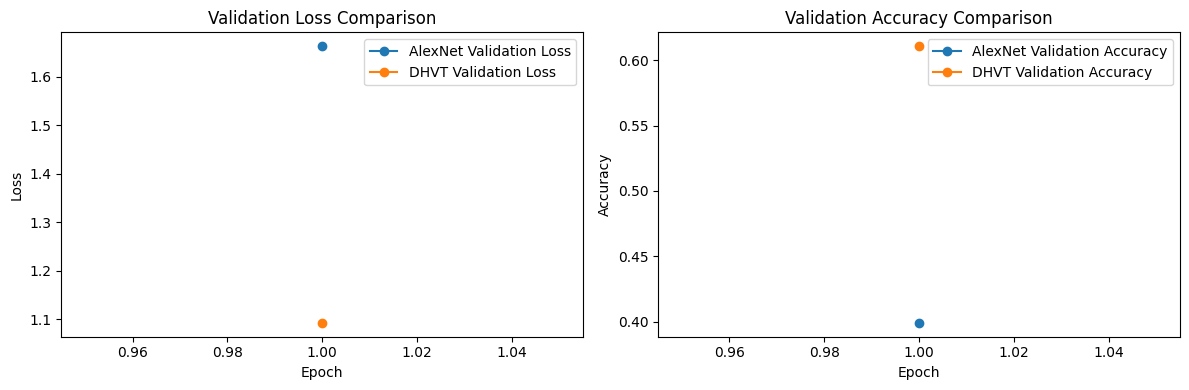

Best AlexNet validation accuracy: 0.3991
Best DHVT validation accuracy: 0.6108


In [34]:
epochs_axis = [item['epoch'] for item in alexnet_history]
alexnet_val_acc = [item['validation_accuracy'] for item in alexnet_history]
dhvt_val_acc = [item['validation_accuracy'] for item in dhvt_history]
alexnet_val_loss = [item['validation_loss'] for item in alexnet_history]
dhvt_val_loss = [item['validation_loss'] for item in dhvt_history]

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_axis, alexnet_val_loss, marker='o', label='AlexNet Validation Loss')
plt.plot(epochs_axis, dhvt_val_loss, marker='o', label='DHVT Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss Comparison')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_axis, alexnet_val_acc, marker='o', label='AlexNet Validation Accuracy')
plt.plot(epochs_axis, dhvt_val_acc, marker='o', label='DHVT Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Comparison')
plt.legend()
plt.tight_layout()
plt.savefig(report_figure_dir / '01_validation_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print('Best AlexNet validation accuracy:', alexnet_best_val_accuracy)
print('Best DHVT validation accuracy:', dhvt_best_val_accuracy)


## 10. Predict the same custom images with both models

In [35]:
image_paths = sorted([path for path in test_images_dir.iterdir() if path.is_file() and path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.webp']])
print('Number of test images found:', len(image_paths))

alexnet_model = AlexNet(num_classes=num_classes).to(device)
alexnet_checkpoint = torch.load(alexnet_best_model_path, map_location=device)
alexnet_model.load_state_dict(alexnet_checkpoint['model_state_dict'])
alexnet_model.eval()

dhvt_model = DHVT(img_size=32, embed_dim=192, depth=12, num_heads=4, num_classes=num_classes).to(device)
dhvt_checkpoint = torch.load(dhvt_best_model_path, map_location=device)
dhvt_model.load_state_dict(dhvt_checkpoint['model_state_dict'])
dhvt_model.eval()


Number of test images found: 3


DHVT(
  (patch_embed): SOPE(
    (conv_layers): Sequential(
      (0): Conv2d(3, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Conv2d(96, 192, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (4): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): GELU(approximate='none')
    )
  )
  (blocks): ModuleList(
    (0-11): 12 x DHVTBlock(
      (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (attn): HeadTokenAttention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (proj): Linear(in_features=192, out_features=192, bias=True)
      )
      (norm2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (mlp): DAFF(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (dwconv): Conv2d(768, 768, kernel_size=(3, 3), stride=(1,

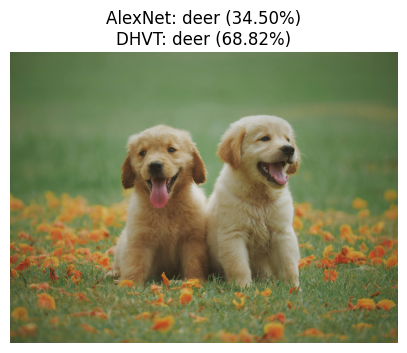

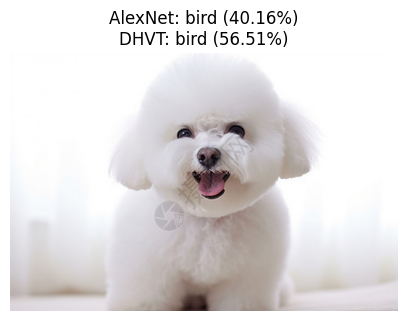

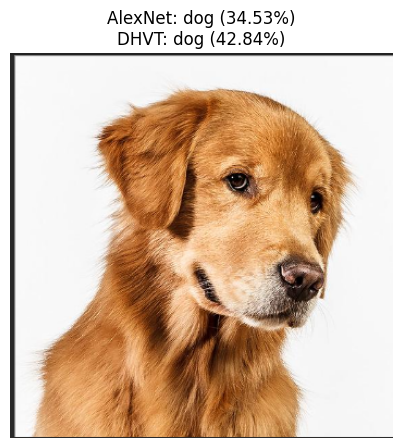

Comparison predictions saved in: /content/drive/MyDrive/classification-deep-learning-project/predictions/cifar10_alexnet_dhvt_comparison.csv


In [36]:
comparison_prediction_file = prediction_dir / f'{dataset_name}_alexnet_dhvt_comparison.csv'

with comparison_prediction_file.open('w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(['image_name', 'alexnet_prediction', 'alexnet_confidence', 'dhvt_prediction', 'dhvt_confidence'])

    for image_path in image_paths:
        img = Image.open(image_path).convert('RGB')
        alexnet_tensor = alexnet_test_transform(img).unsqueeze(0).to(device)
        dhvt_tensor = dhvt_test_transform(img).unsqueeze(0).to(device)

        with torch.inference_mode():
            alexnet_output = alexnet_model(alexnet_tensor)
            alexnet_probabilities = torch.softmax(alexnet_output[0], dim=0)
            alexnet_confidence, alexnet_predicted = torch.max(alexnet_probabilities, 0)

            dhvt_output = dhvt_model(dhvt_tensor)
            dhvt_probabilities = torch.softmax(dhvt_output[0], dim=0)
            dhvt_confidence, dhvt_predicted = torch.max(dhvt_probabilities, 0)

        alexnet_label = classes[alexnet_predicted.item()]
        dhvt_label = classes[dhvt_predicted.item()]
        writer.writerow([image_path.name, alexnet_label, f'{alexnet_confidence.item():.6f}', dhvt_label, f'{dhvt_confidence.item():.6f}'])

        plt.figure(figsize=(5, 5))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f'AlexNet: {alexnet_label} ({alexnet_confidence.item() * 100:.2f}%)\nDHVT: {dhvt_label} ({dhvt_confidence.item() * 100:.2f}%)')
        plt.show()

print('Comparison predictions saved in:', comparison_prediction_file)


## 11. Confusion Matrices

In [37]:
alexnet_confusion = torch.zeros(num_classes, num_classes, dtype=torch.int64)
dhvt_confusion = torch.zeros(num_classes, num_classes, dtype=torch.int64)

alexnet_predictions_all = []
dhvt_predictions_all = []
alexnet_labels_all = []
dhvt_labels_all = []
alexnet_confidences = []
dhvt_confidences = []
alexnet_correct_confidences = []
alexnet_wrong_confidences = []
dhvt_correct_confidences = []
dhvt_wrong_confidences = []

alexnet_model.eval()
with torch.inference_mode():
    for alex_inputs, labels in alexnet_testloader:
        alex_inputs, labels = alex_inputs.to(device), labels.to(device)
        alex_outputs = alexnet_model(alex_inputs)
        alex_probs = torch.softmax(alex_outputs, dim=1)
        alex_conf, alex_preds = alex_probs.max(dim=1)

        alexnet_predictions_all.extend(alex_preds.cpu().tolist())
        alexnet_labels_all.extend(labels.cpu().tolist())
        alexnet_confidences.extend(alex_conf.cpu().tolist())

        for confidence, true_label, alex_pred in zip(alex_conf.cpu(), labels.cpu(), alex_preds.cpu()):
            alexnet_confusion[true_label, alex_pred] += 1
            if alex_pred == true_label:
                alexnet_correct_confidences.append(confidence.item())
            else:
                alexnet_wrong_confidences.append(confidence.item())

dhvt_model.eval()
with torch.inference_mode():
    for dhvt_inputs, labels in dhvt_testloader:
        dhvt_inputs, labels = dhvt_inputs.to(device), labels.to(device)
        dhvt_outputs = dhvt_model(dhvt_inputs)
        dhvt_probs = torch.softmax(dhvt_outputs, dim=1)
        dhvt_conf, dhvt_preds = dhvt_probs.max(dim=1)

        dhvt_predictions_all.extend(dhvt_preds.cpu().tolist())
        dhvt_labels_all.extend(labels.cpu().tolist())
        dhvt_confidences.extend(dhvt_conf.cpu().tolist())

        for confidence, true_label, dhvt_pred in zip(dhvt_conf.cpu(), labels.cpu(), dhvt_preds.cpu()):
            dhvt_confusion[true_label, dhvt_pred] += 1
            if dhvt_pred == true_label:
                dhvt_correct_confidences.append(confidence.item())
            else:
                dhvt_wrong_confidences.append(confidence.item())

if alexnet_labels_all != dhvt_labels_all:
    raise ValueError('The label order of AlexNet and DHVT evaluation loaders does not match.')

labels_all = alexnet_labels_all
alexnet_class_totals = alexnet_confusion.sum(dim=1)
dhvt_class_totals = dhvt_confusion.sum(dim=1)

if not torch.equal(alexnet_class_totals, dhvt_class_totals):
    raise ValueError('AlexNet and DHVT have inconsistent per-class sample totals. Check the evaluation datasets and label mapping.')

class_sample_totals = alexnet_class_totals

print('Confusion matrices computed successfully with aligned evaluation labels.')
print('Per-class sample totals:', {classes[i]: int(class_sample_totals[i].item()) for i in range(num_classes)})


Confusion matrices computed successfully with aligned evaluation labels.
Per-class sample totals: {'airplane': 1000, 'automobile': 1000, 'bird': 1000, 'cat': 1000, 'deer': 1000, 'dog': 1000, 'frog': 1000, 'horse': 1000, 'ship': 1000, 'truck': 1000}


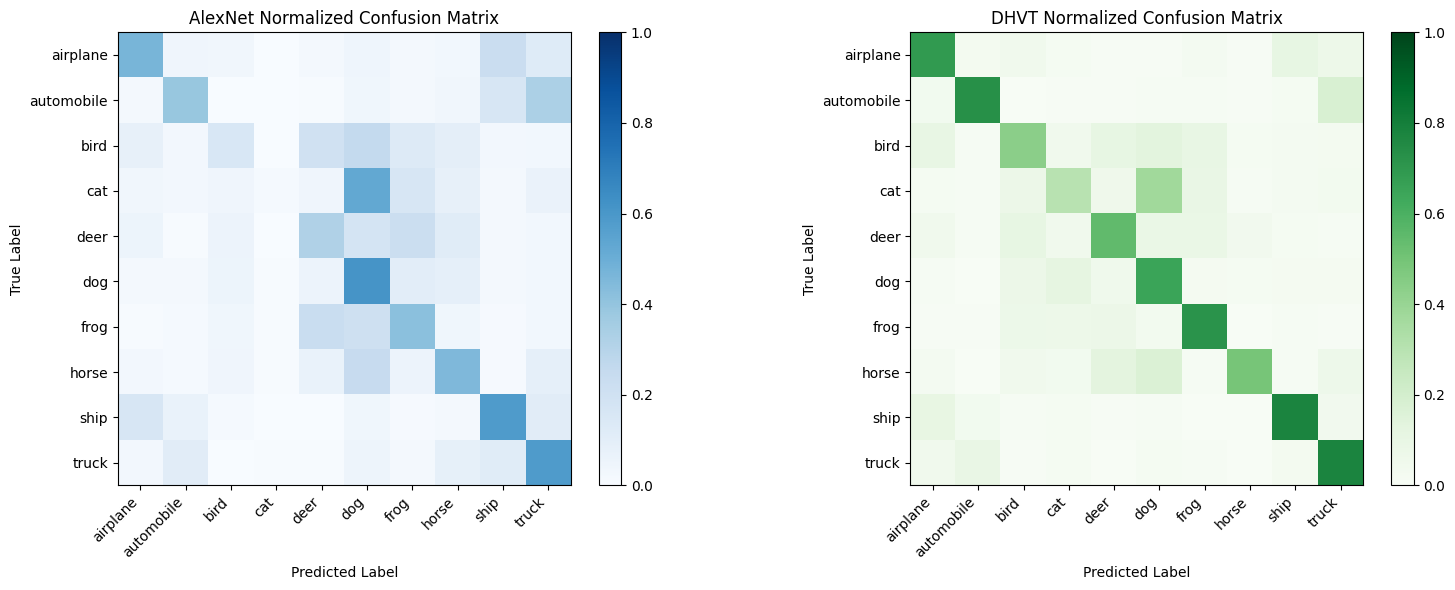

Top AlexNet confusion pairs:
  cat -> dog: 527
  automobile -> truck: 332
  bird -> dog: 257
  horse -> dog: 245
  frog -> deer: 233
Top DHVT confusion pairs:
  cat -> dog: 373
  automobile -> truck: 179
  horse -> dog: 166
  bird -> dog: 130
  horse -> deer: 128


In [38]:
alexnet_confusion_normalized = alexnet_confusion.float() / alexnet_confusion.sum(dim=1, keepdim=True).clamp(min=1)
dhvt_confusion_normalized = dhvt_confusion.float() / dhvt_confusion.sum(dim=1, keepdim=True).clamp(min=1)

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.imshow(alexnet_confusion_normalized.numpy(), cmap='Blues', vmin=0.0, vmax=1.0)
plt.title('AlexNet Normalized Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(np.arange(num_classes), classes, rotation=45, ha='right')
plt.yticks(np.arange(num_classes), classes)
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1, 2, 2)
plt.imshow(dhvt_confusion_normalized.numpy(), cmap='Greens', vmin=0.0, vmax=1.0)
plt.title('DHVT Normalized Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(np.arange(num_classes), classes, rotation=45, ha='right')
plt.yticks(np.arange(num_classes), classes)
plt.colorbar(fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(report_figure_dir / '02_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

alexnet_off_diagonal = alexnet_confusion.clone()
dhvt_off_diagonal = dhvt_confusion.clone()
alexnet_off_diagonal.fill_diagonal_(0)
dhvt_off_diagonal.fill_diagonal_(0)

alexnet_top_values, alexnet_top_indices = torch.topk(alexnet_off_diagonal.flatten(), k=min(5, num_classes * num_classes))
dhvt_top_values, dhvt_top_indices = torch.topk(dhvt_off_diagonal.flatten(), k=min(5, num_classes * num_classes))

print('Top AlexNet confusion pairs:')
for value, flat_index in zip(alexnet_top_values.tolist(), alexnet_top_indices.tolist()):
    if value <= 0:
        continue
    true_index = flat_index // num_classes
    predicted_index = flat_index % num_classes
    print(f"  {classes[true_index]} -> {classes[predicted_index]}: {value}")

print('Top DHVT confusion pairs:')
for value, flat_index in zip(dhvt_top_values.tolist(), dhvt_top_indices.tolist()):
    if value <= 0:
        continue
    true_index = flat_index // num_classes
    predicted_index = flat_index % num_classes
    print(f"  {classes[true_index]} -> {classes[predicted_index]}: {value}")


## 12. Per-Class Accuracy

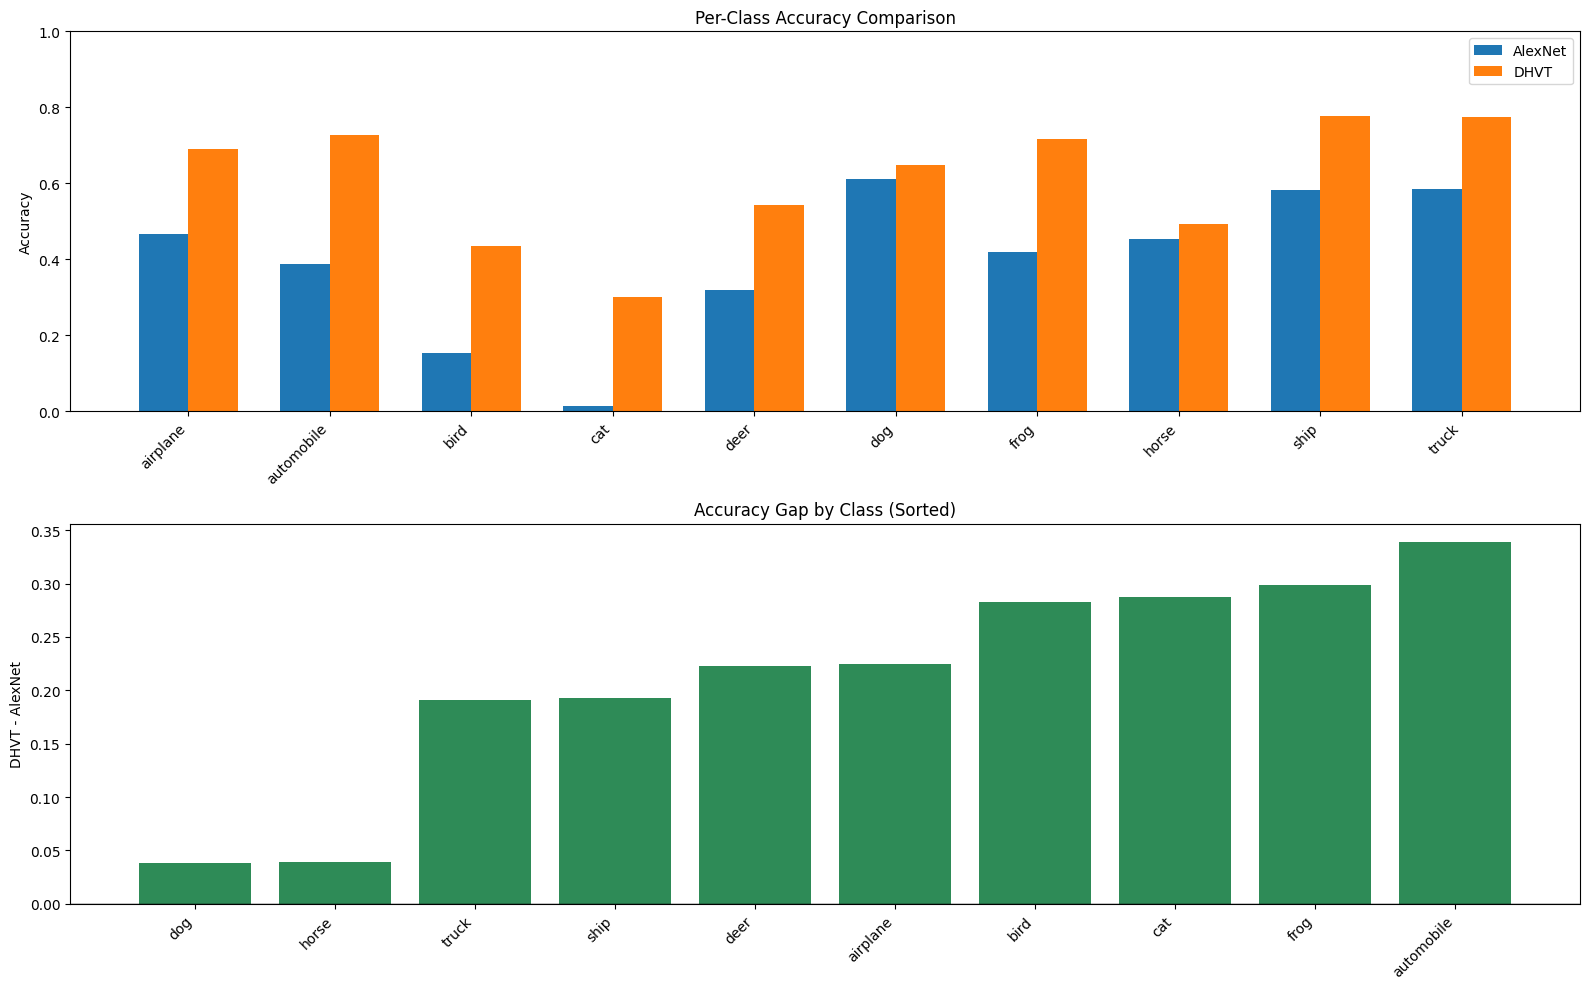

Per-class accuracy summary:
  automobile | samples: 1000 | AlexNet: 0.3890 | DHVT: 0.7280 | gap: +0.3390
  frog | samples: 1000 | AlexNet: 0.4190 | DHVT: 0.7180 | gap: +0.2990
  cat | samples: 1000 | AlexNet: 0.0130 | DHVT: 0.3000 | gap: +0.2870
  bird | samples: 1000 | AlexNet: 0.1530 | DHVT: 0.4360 | gap: +0.2830
  airplane | samples: 1000 | AlexNet: 0.4660 | DHVT: 0.6910 | gap: +0.2250
  deer | samples: 1000 | AlexNet: 0.3200 | DHVT: 0.5430 | gap: +0.2230
  ship | samples: 1000 | AlexNet: 0.5830 | DHVT: 0.7760 | gap: +0.1930
  truck | samples: 1000 | AlexNet: 0.5840 | DHVT: 0.7750 | gap: +0.1910
  horse | samples: 1000 | AlexNet: 0.4530 | DHVT: 0.4920 | gap: +0.0390
  dog | samples: 1000 | AlexNet: 0.6110 | DHVT: 0.6490 | gap: +0.0380


In [39]:
alexnet_per_class_accuracy = []
dhvt_per_class_accuracy = []

for class_index in range(num_classes):
    alexnet_class_total = alexnet_class_totals[class_index].item()
    dhvt_class_total = dhvt_class_totals[class_index].item()
    alexnet_class_correct = alexnet_confusion[class_index, class_index].item()
    dhvt_class_correct = dhvt_confusion[class_index, class_index].item()

    if alexnet_class_total == 0:
        alexnet_per_class_accuracy.append(0.0)
    else:
        alexnet_per_class_accuracy.append(alexnet_class_correct / alexnet_class_total)

    if dhvt_class_total == 0:
        dhvt_per_class_accuracy.append(0.0)
    else:
        dhvt_per_class_accuracy.append(dhvt_class_correct / dhvt_class_total)

accuracy_gap = [dhvt_acc - alexnet_acc for alexnet_acc, dhvt_acc in zip(alexnet_per_class_accuracy, dhvt_per_class_accuracy)]
sorted_indices = np.argsort(accuracy_gap)
sorted_class_names = [classes[index] for index in sorted_indices]
sorted_accuracy_gap = [accuracy_gap[index] for index in sorted_indices]
gap_colors = ['seagreen' if value >= 0 else 'indianred' for value in sorted_accuracy_gap]

x = np.arange(num_classes)
width = 0.35

plt.figure(figsize=(16, 10))
plt.subplot(2, 1, 1)
plt.bar(x - width / 2, alexnet_per_class_accuracy, width=width, label='AlexNet')
plt.bar(x + width / 2, dhvt_per_class_accuracy, width=width, label='DHVT')
plt.xticks(x, classes, rotation=45, ha='right')
plt.ylabel('Accuracy')
plt.title('Per-Class Accuracy Comparison')
plt.ylim(0, 1.0)
plt.legend()

plt.subplot(2, 1, 2)
plt.bar(np.arange(num_classes), sorted_accuracy_gap, color=gap_colors)
plt.axhline(0.0, color='black', linewidth=1)
plt.xticks(np.arange(num_classes), sorted_class_names, rotation=45, ha='right')
plt.ylabel('DHVT - AlexNet')
plt.title('Accuracy Gap by Class (Sorted)')
plt.tight_layout()
plt.savefig(report_figure_dir / '07_per_class_accuracy_gap.png', dpi=300, bbox_inches='tight')
plt.show()

print('Per-class accuracy summary:')
for class_index in np.argsort(accuracy_gap)[::-1]:
    print(
        f"  {classes[class_index]} | samples: {int(class_sample_totals[class_index].item())} | "
        f"AlexNet: {alexnet_per_class_accuracy[class_index]:.4f} | "
        f"DHVT: {dhvt_per_class_accuracy[class_index]:.4f} | "
        f"gap: {accuracy_gap[class_index]:+.4f}"
    )


## 13. Parameter Count Comparison

In [40]:
alexnet_num_params = sum(p.numel() for p in alexnet_model.parameters())
dhvt_num_params = sum(p.numel() for p in dhvt_model.parameters())

print('AlexNet number of parameters:', alexnet_num_params)
print('DHVT number of parameters:', dhvt_num_params)

AlexNet number of parameters: 58322314
DHVT number of parameters: 6504202


## 14. Misclassified Examples

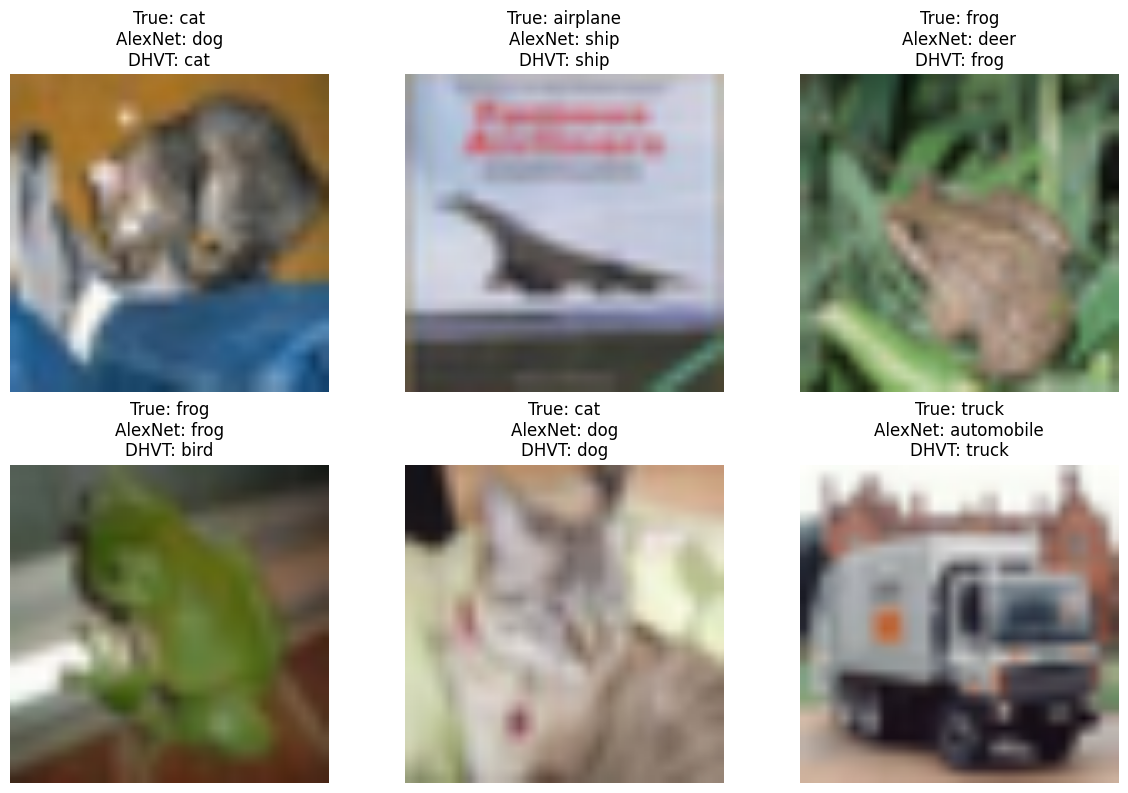

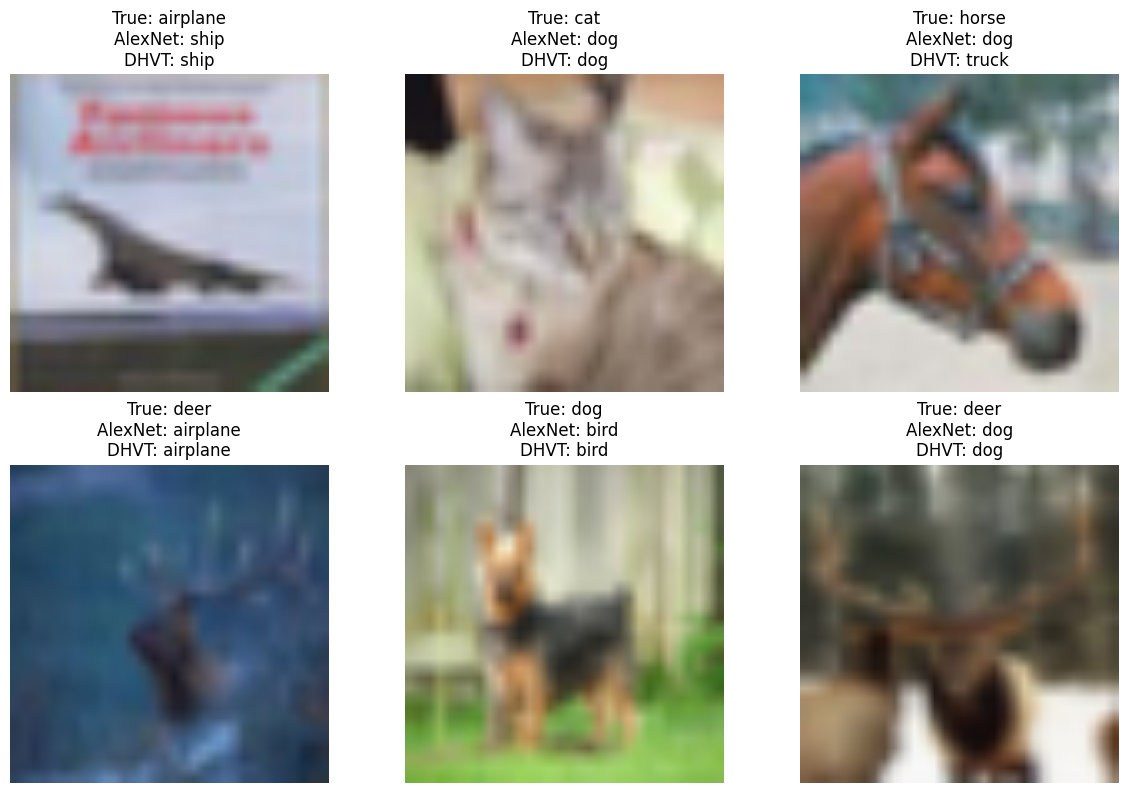

In [41]:
misclassified_examples = []
both_wrong_examples = []

alexnet_eval_for_images = datasets.CIFAR10(root=str(data_dir), train=False, download=True, transform=alexnet_test_transform) if dataset_name == 'cifar10' else None
if dataset_name == 'cifar100':
    alexnet_eval_for_images = datasets.CIFAR100(root=str(data_dir), train=False, download=True, transform=alexnet_test_transform)

if alexnet_eval_for_images is not None:
    for index in range(len(labels_all)):
        true_label = labels_all[index]
        alex_pred = alexnet_predictions_all[index]
        dhvt_pred = dhvt_predictions_all[index]
        image_tensor, _ = alexnet_eval_for_images[index]

        if alex_pred != true_label or dhvt_pred != true_label:
            misclassified_examples.append((image_tensor, true_label, alex_pred, dhvt_pred))

        if alex_pred != true_label and dhvt_pred != true_label:
            both_wrong_examples.append((image_tensor, true_label, alex_pred, dhvt_pred))

        if len(misclassified_examples) >= 6 and len(both_wrong_examples) >= 6:
            break

    plt.figure(figsize=(12, 8))
    for i, (image_tensor, true_label, alex_pred, dhvt_pred) in enumerate(misclassified_examples[:6], start=1):
        image = image_tensor.permute(1, 2, 0).numpy()
        image = (image * 0.5) + 0.5
        image = np.clip(image, 0, 1)
        plt.subplot(2, 3, i)
        plt.imshow(image)
        plt.axis('off')
        plt.title(f'True: {classes[true_label]}\nAlexNet: {classes[alex_pred]}\nDHVT: {classes[dhvt_pred]}')

    plt.tight_layout()
    plt.savefig(report_figure_dir / '03_misclassified_examples.png', dpi=300, bbox_inches='tight')
    plt.show()

    if len(both_wrong_examples) > 0:
        plt.figure(figsize=(12, 8))
        for i, (image_tensor, true_label, alex_pred, dhvt_pred) in enumerate(both_wrong_examples[:6], start=1):
            image = image_tensor.permute(1, 2, 0).numpy()
            image = (image * 0.5) + 0.5
            image = np.clip(image, 0, 1)
            plt.subplot(2, 3, i)
            plt.imshow(image)
            plt.axis('off')
            plt.title(f'True: {classes[true_label]}\nAlexNet: {classes[alex_pred]}\nDHVT: {classes[dhvt_pred]}')

        plt.tight_layout()
        plt.savefig(report_figure_dir / '04_both_models_wrong_examples.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print('No samples were misclassified by both models in the current evaluation set.')
else:
    print('Misclassified example visualization is prepared for CIFAR datasets in this notebook.')


## 15. Precision, Recall, and F1-Score by Class


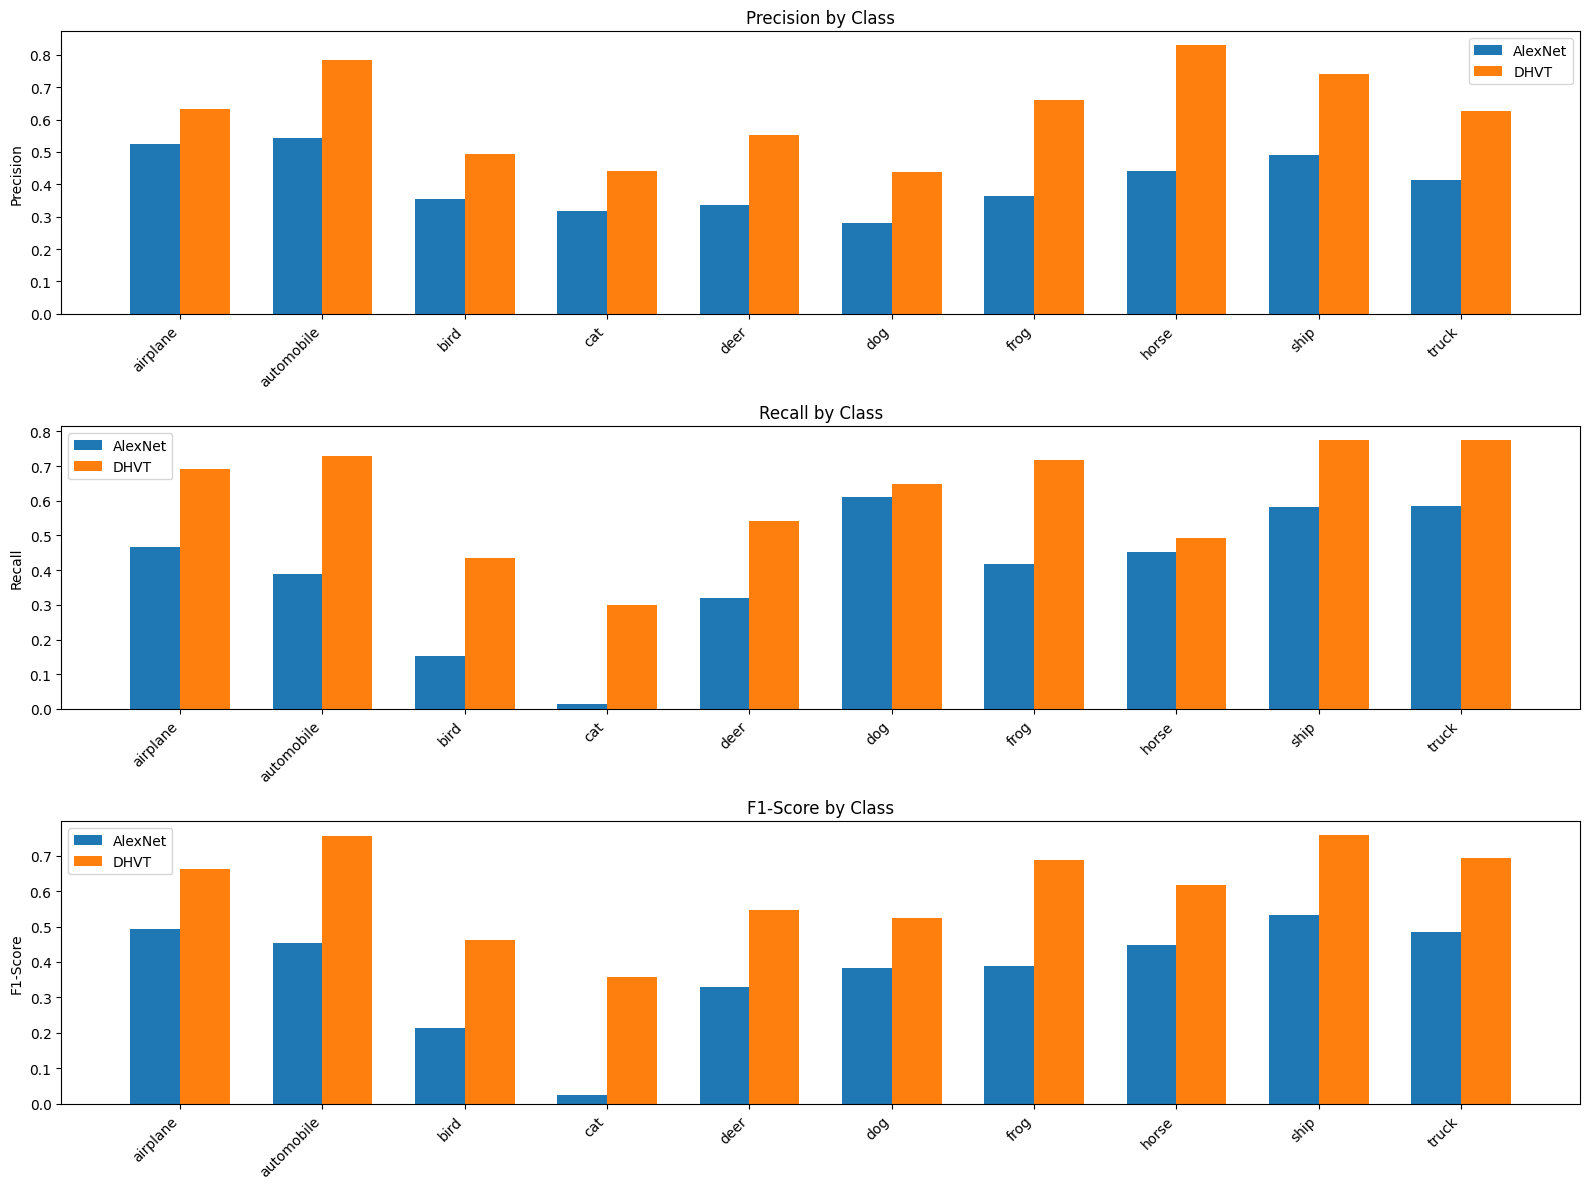

AlexNet macro precision: 0.4063052553835439
AlexNet macro recall: 0.3991
AlexNet macro F1: 0.3749694785581207
DHVT macro precision: 0.6207206972103212
DHVT macro recall: 0.6108
DHVT macro F1: 0.6067173757645443


In [42]:
alexnet_precision = []
alexnet_recall = []
alexnet_f1 = []
dhvt_precision = []
dhvt_recall = []
dhvt_f1 = []

for class_index in range(num_classes):
    alex_tp = alexnet_confusion[class_index, class_index].item()
    alex_fp = alexnet_confusion[:, class_index].sum().item() - alex_tp
    alex_fn = alexnet_confusion[class_index, :].sum().item() - alex_tp

    dhvt_tp = dhvt_confusion[class_index, class_index].item()
    dhvt_fp = dhvt_confusion[:, class_index].sum().item() - dhvt_tp
    dhvt_fn = dhvt_confusion[class_index, :].sum().item() - dhvt_tp

    alex_p = alex_tp / (alex_tp + alex_fp) if (alex_tp + alex_fp) > 0 else 0.0
    alex_r = alex_tp / (alex_tp + alex_fn) if (alex_tp + alex_fn) > 0 else 0.0
    alex_f = 2 * alex_p * alex_r / (alex_p + alex_r) if (alex_p + alex_r) > 0 else 0.0

    dhvt_p = dhvt_tp / (dhvt_tp + dhvt_fp) if (dhvt_tp + dhvt_fp) > 0 else 0.0
    dhvt_r = dhvt_tp / (dhvt_tp + dhvt_fn) if (dhvt_tp + dhvt_fn) > 0 else 0.0
    dhvt_f = 2 * dhvt_p * dhvt_r / (dhvt_p + dhvt_r) if (dhvt_p + dhvt_r) > 0 else 0.0

    alexnet_precision.append(alex_p)
    alexnet_recall.append(alex_r)
    alexnet_f1.append(alex_f)
    dhvt_precision.append(dhvt_p)
    dhvt_recall.append(dhvt_r)
    dhvt_f1.append(dhvt_f)

x = np.arange(num_classes)
width = 0.35

plt.figure(figsize=(16, 12))
plt.subplot(3, 1, 1)
plt.bar(x - width / 2, alexnet_precision, width=width, label='AlexNet')
plt.bar(x + width / 2, dhvt_precision, width=width, label='DHVT')
plt.xticks(x, classes, rotation=45, ha='right')
plt.ylabel('Precision')
plt.title('Precision by Class')
plt.legend()

plt.subplot(3, 1, 2)
plt.bar(x - width / 2, alexnet_recall, width=width, label='AlexNet')
plt.bar(x + width / 2, dhvt_recall, width=width, label='DHVT')
plt.xticks(x, classes, rotation=45, ha='right')
plt.ylabel('Recall')
plt.title('Recall by Class')
plt.legend()

plt.subplot(3, 1, 3)
plt.bar(x - width / 2, alexnet_f1, width=width, label='AlexNet')
plt.bar(x + width / 2, dhvt_f1, width=width, label='DHVT')
plt.xticks(x, classes, rotation=45, ha='right')
plt.ylabel('F1-Score')
plt.title('F1-Score by Class')
plt.legend()
plt.tight_layout()
plt.show()

print('AlexNet macro precision:', float(np.mean(alexnet_precision)))
print('AlexNet macro recall:', float(np.mean(alexnet_recall)))
print('AlexNet macro F1:', float(np.mean(alexnet_f1)))
print('DHVT macro precision:', float(np.mean(dhvt_precision)))
print('DHVT macro recall:', float(np.mean(dhvt_recall)))
print('DHVT macro F1:', float(np.mean(dhvt_f1)))


## 16. Confidence Distribution and Error Confidence


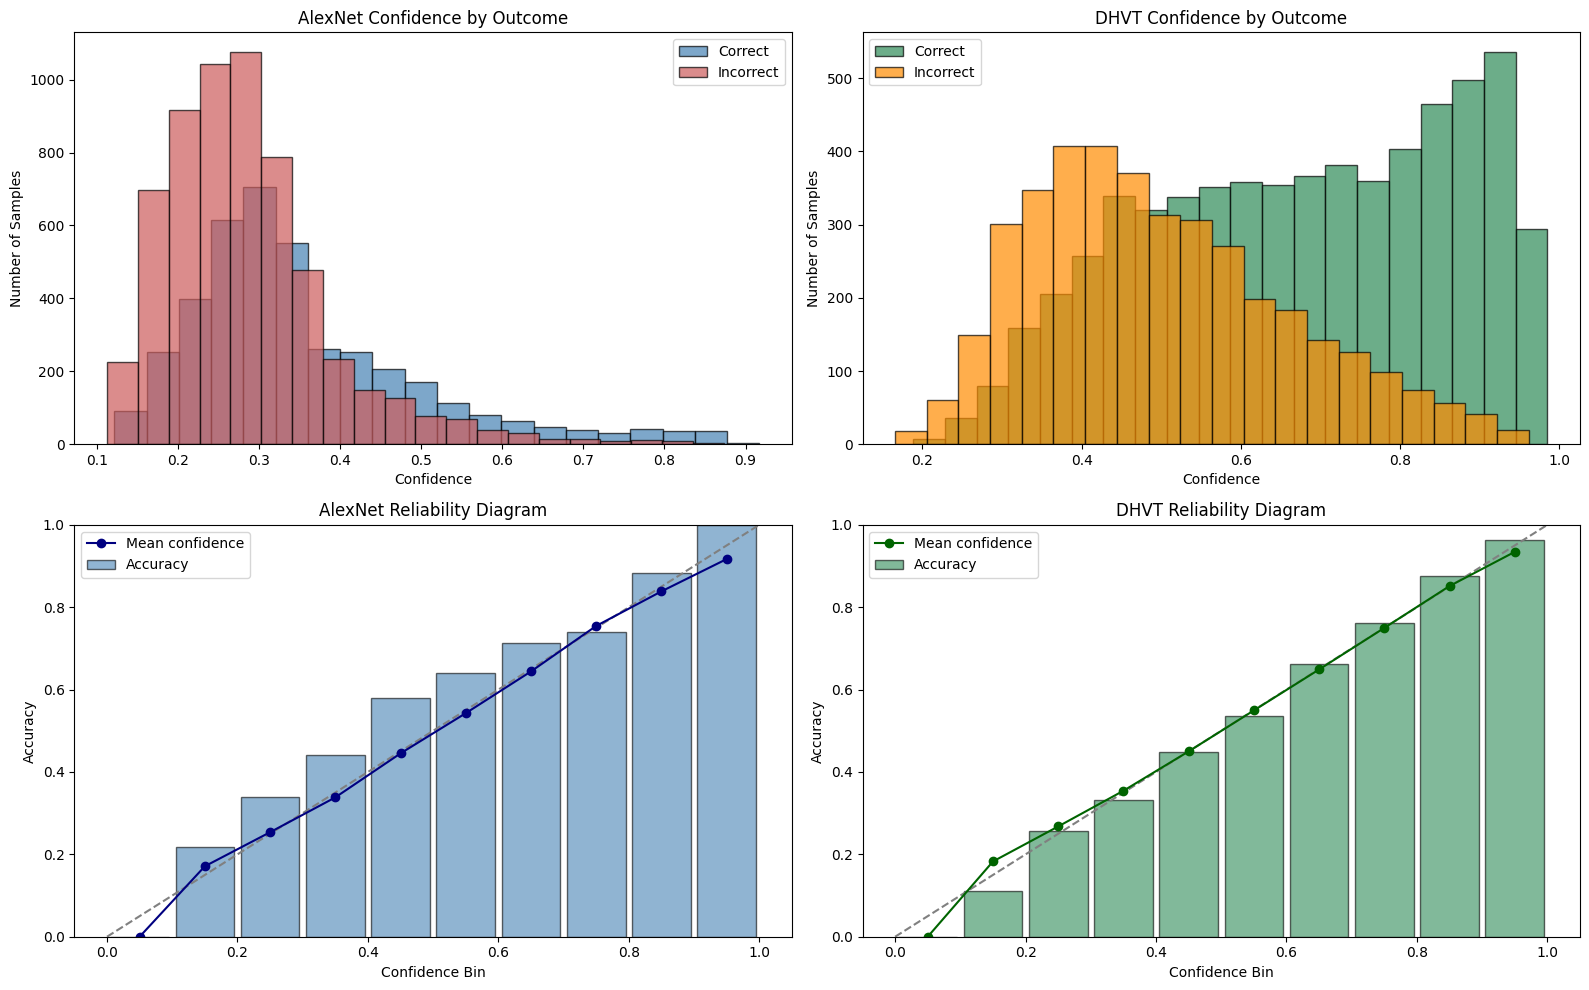

AlexNet mean confidence: 0.3122629066631198
AlexNet mean confidence on correct predictions: 0.3550592548165128
AlexNet mean confidence on incorrect predictions: 0.28383883851863795
AlexNet ECE: 0.08719171525985003
DHVT mean confidence: 0.6072787307605148
DHVT mean confidence on correct predictions: 0.6776923169116609
DHVT mean confidence on incorrect predictions: 0.496773544683639
DHVT ECE: 0.014809716366231445


In [43]:
alexnet_confidences_np = np.array(alexnet_confidences)
dhvt_confidences_np = np.array(dhvt_confidences)
labels_all_np = np.array(labels_all)
alexnet_predictions_all_np = np.array(alexnet_predictions_all)
dhvt_predictions_all_np = np.array(dhvt_predictions_all)
alexnet_correct_mask = alexnet_predictions_all_np == labels_all_np
dhvt_correct_mask = dhvt_predictions_all_np == labels_all_np

bin_edges = np.linspace(0.0, 1.0, 11)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
alexnet_bin_accuracy = []
alexnet_bin_confidence = []
dhvt_bin_accuracy = []
dhvt_bin_confidence = []
alexnet_ece = 0.0
dhvt_ece = 0.0

for left_edge, right_edge in zip(bin_edges[:-1], bin_edges[1:]):
    alexnet_mask = (alexnet_confidences_np >= left_edge) & (alexnet_confidences_np < right_edge)
    dhvt_mask = (dhvt_confidences_np >= left_edge) & (dhvt_confidences_np < right_edge)

    if right_edge == 1.0:
        alexnet_mask = (alexnet_confidences_np >= left_edge) & (alexnet_confidences_np <= right_edge)
        dhvt_mask = (dhvt_confidences_np >= left_edge) & (dhvt_confidences_np <= right_edge)

    if alexnet_mask.any():
        bin_accuracy = float(alexnet_correct_mask[alexnet_mask].mean())
        bin_confidence = float(alexnet_confidences_np[alexnet_mask].mean())
        alexnet_ece += abs(bin_accuracy - bin_confidence) * float(alexnet_mask.mean())
    else:
        bin_accuracy = np.nan
        bin_confidence = np.nan
    alexnet_bin_accuracy.append(bin_accuracy)
    alexnet_bin_confidence.append(bin_confidence)

    if dhvt_mask.any():
        bin_accuracy = float(dhvt_correct_mask[dhvt_mask].mean())
        bin_confidence = float(dhvt_confidences_np[dhvt_mask].mean())
        dhvt_ece += abs(bin_accuracy - bin_confidence) * float(dhvt_mask.mean())
    else:
        bin_accuracy = np.nan
        bin_confidence = np.nan
    dhvt_bin_accuracy.append(bin_accuracy)
    dhvt_bin_confidence.append(bin_confidence)

plt.figure(figsize=(16, 10))
plt.subplot(2, 2, 1)
plt.hist(alexnet_correct_confidences, bins=20, alpha=0.7, label='Correct', color='steelblue', edgecolor='black')
plt.hist(alexnet_wrong_confidences, bins=20, alpha=0.7, label='Incorrect', color='indianred', edgecolor='black')
plt.title('AlexNet Confidence by Outcome')
plt.xlabel('Confidence')
plt.ylabel('Number of Samples')
plt.legend()

plt.subplot(2, 2, 2)
plt.hist(dhvt_correct_confidences, bins=20, alpha=0.7, label='Correct', color='seagreen', edgecolor='black')
plt.hist(dhvt_wrong_confidences, bins=20, alpha=0.7, label='Incorrect', color='darkorange', edgecolor='black')
plt.title('DHVT Confidence by Outcome')
plt.xlabel('Confidence')
plt.ylabel('Number of Samples')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.bar(bin_centers, np.nan_to_num(alexnet_bin_accuracy, nan=0.0), width=0.09, alpha=0.6, color='steelblue', edgecolor='black', label='Accuracy')
plt.plot(bin_centers, np.nan_to_num(alexnet_bin_confidence, nan=0.0), marker='o', color='navy', label='Mean confidence')
plt.title('AlexNet Reliability Diagram')
plt.xlabel('Confidence Bin')
plt.ylabel('Accuracy')
plt.ylim(0, 1.0)
plt.legend()

plt.subplot(2, 2, 4)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.bar(bin_centers, np.nan_to_num(dhvt_bin_accuracy, nan=0.0), width=0.09, alpha=0.6, color='seagreen', edgecolor='black', label='Accuracy')
plt.plot(bin_centers, np.nan_to_num(dhvt_bin_confidence, nan=0.0), marker='o', color='darkgreen', label='Mean confidence')
plt.title('DHVT Reliability Diagram')
plt.xlabel('Confidence Bin')
plt.ylabel('Accuracy')
plt.ylim(0, 1.0)
plt.legend()

plt.tight_layout()
plt.savefig(report_figure_dir / '05_confidence_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print('AlexNet mean confidence:', float(np.mean(alexnet_confidences_np)))
print('AlexNet mean confidence on correct predictions:', float(np.mean(alexnet_correct_confidences)))
print('AlexNet mean confidence on incorrect predictions:', float(np.mean(alexnet_wrong_confidences)))
print('AlexNet ECE:', alexnet_ece)
print('DHVT mean confidence:', float(np.mean(dhvt_confidences_np)))
print('DHVT mean confidence on correct predictions:', float(np.mean(dhvt_correct_confidences)))
print('DHVT mean confidence on incorrect predictions:', float(np.mean(dhvt_wrong_confidences)))
print('DHVT ECE:', dhvt_ece)


## 17. Agreement and Disagreement Analysis


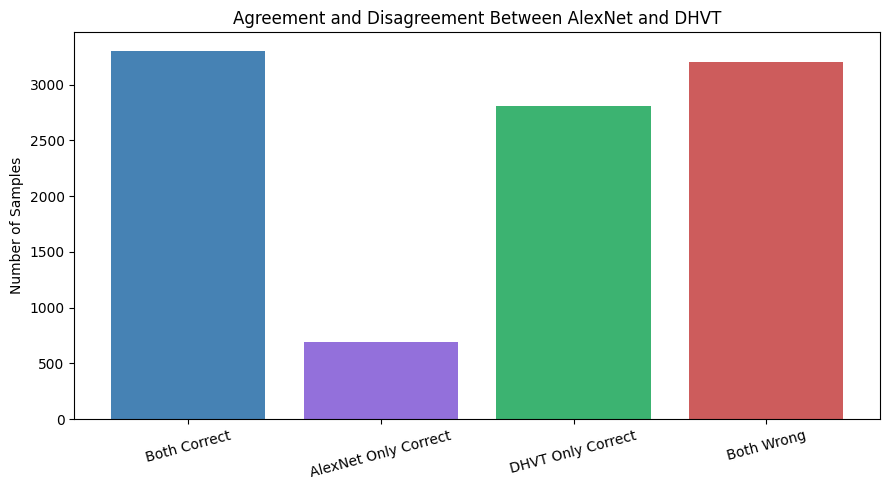

Both correct ratio: 0.3303
AlexNet only correct ratio: 0.0688
DHVT only correct ratio: 0.2805
Both wrong ratio: 0.3204


In [44]:
both_correct = 0
alexnet_only_correct = 0
dhvt_only_correct = 0
both_wrong = 0

for true_label, alex_pred, dhvt_pred in zip(labels_all, alexnet_predictions_all, dhvt_predictions_all):
    alex_correct = alex_pred == true_label
    dhvt_correct = dhvt_pred == true_label

    if alex_correct and dhvt_correct:
        both_correct += 1
    elif alex_correct and not dhvt_correct:
        alexnet_only_correct += 1
    elif not alex_correct and dhvt_correct:
        dhvt_only_correct += 1
    else:
        both_wrong += 1

agreement_labels = ['Both Correct', 'AlexNet Only Correct', 'DHVT Only Correct', 'Both Wrong']
agreement_values = [both_correct, alexnet_only_correct, dhvt_only_correct, both_wrong]
agreement_colors = ['steelblue', 'mediumpurple', 'mediumseagreen', 'indianred']

plt.figure(figsize=(9, 5))
plt.bar(agreement_labels, agreement_values, color=agreement_colors)
plt.ylabel('Number of Samples')
plt.title('Agreement and Disagreement Between AlexNet and DHVT')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(report_figure_dir / '06_agreement_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

total_compared = len(labels_all)
print('Both correct ratio:', both_correct / total_compared)
print('AlexNet only correct ratio:', alexnet_only_correct / total_compared)
print('DHVT only correct ratio:', dhvt_only_correct / total_compared)
print('Both wrong ratio:', both_wrong / total_compared)


## 18. DHVT Attention Visualization

This section visualizes DHVT attention on representative validation samples. It includes examples where DHVT is correct while AlexNet is wrong, as well as DHVT failure cases, so that the attention maps can support the qualitative analysis before the final discussion and conclusion.


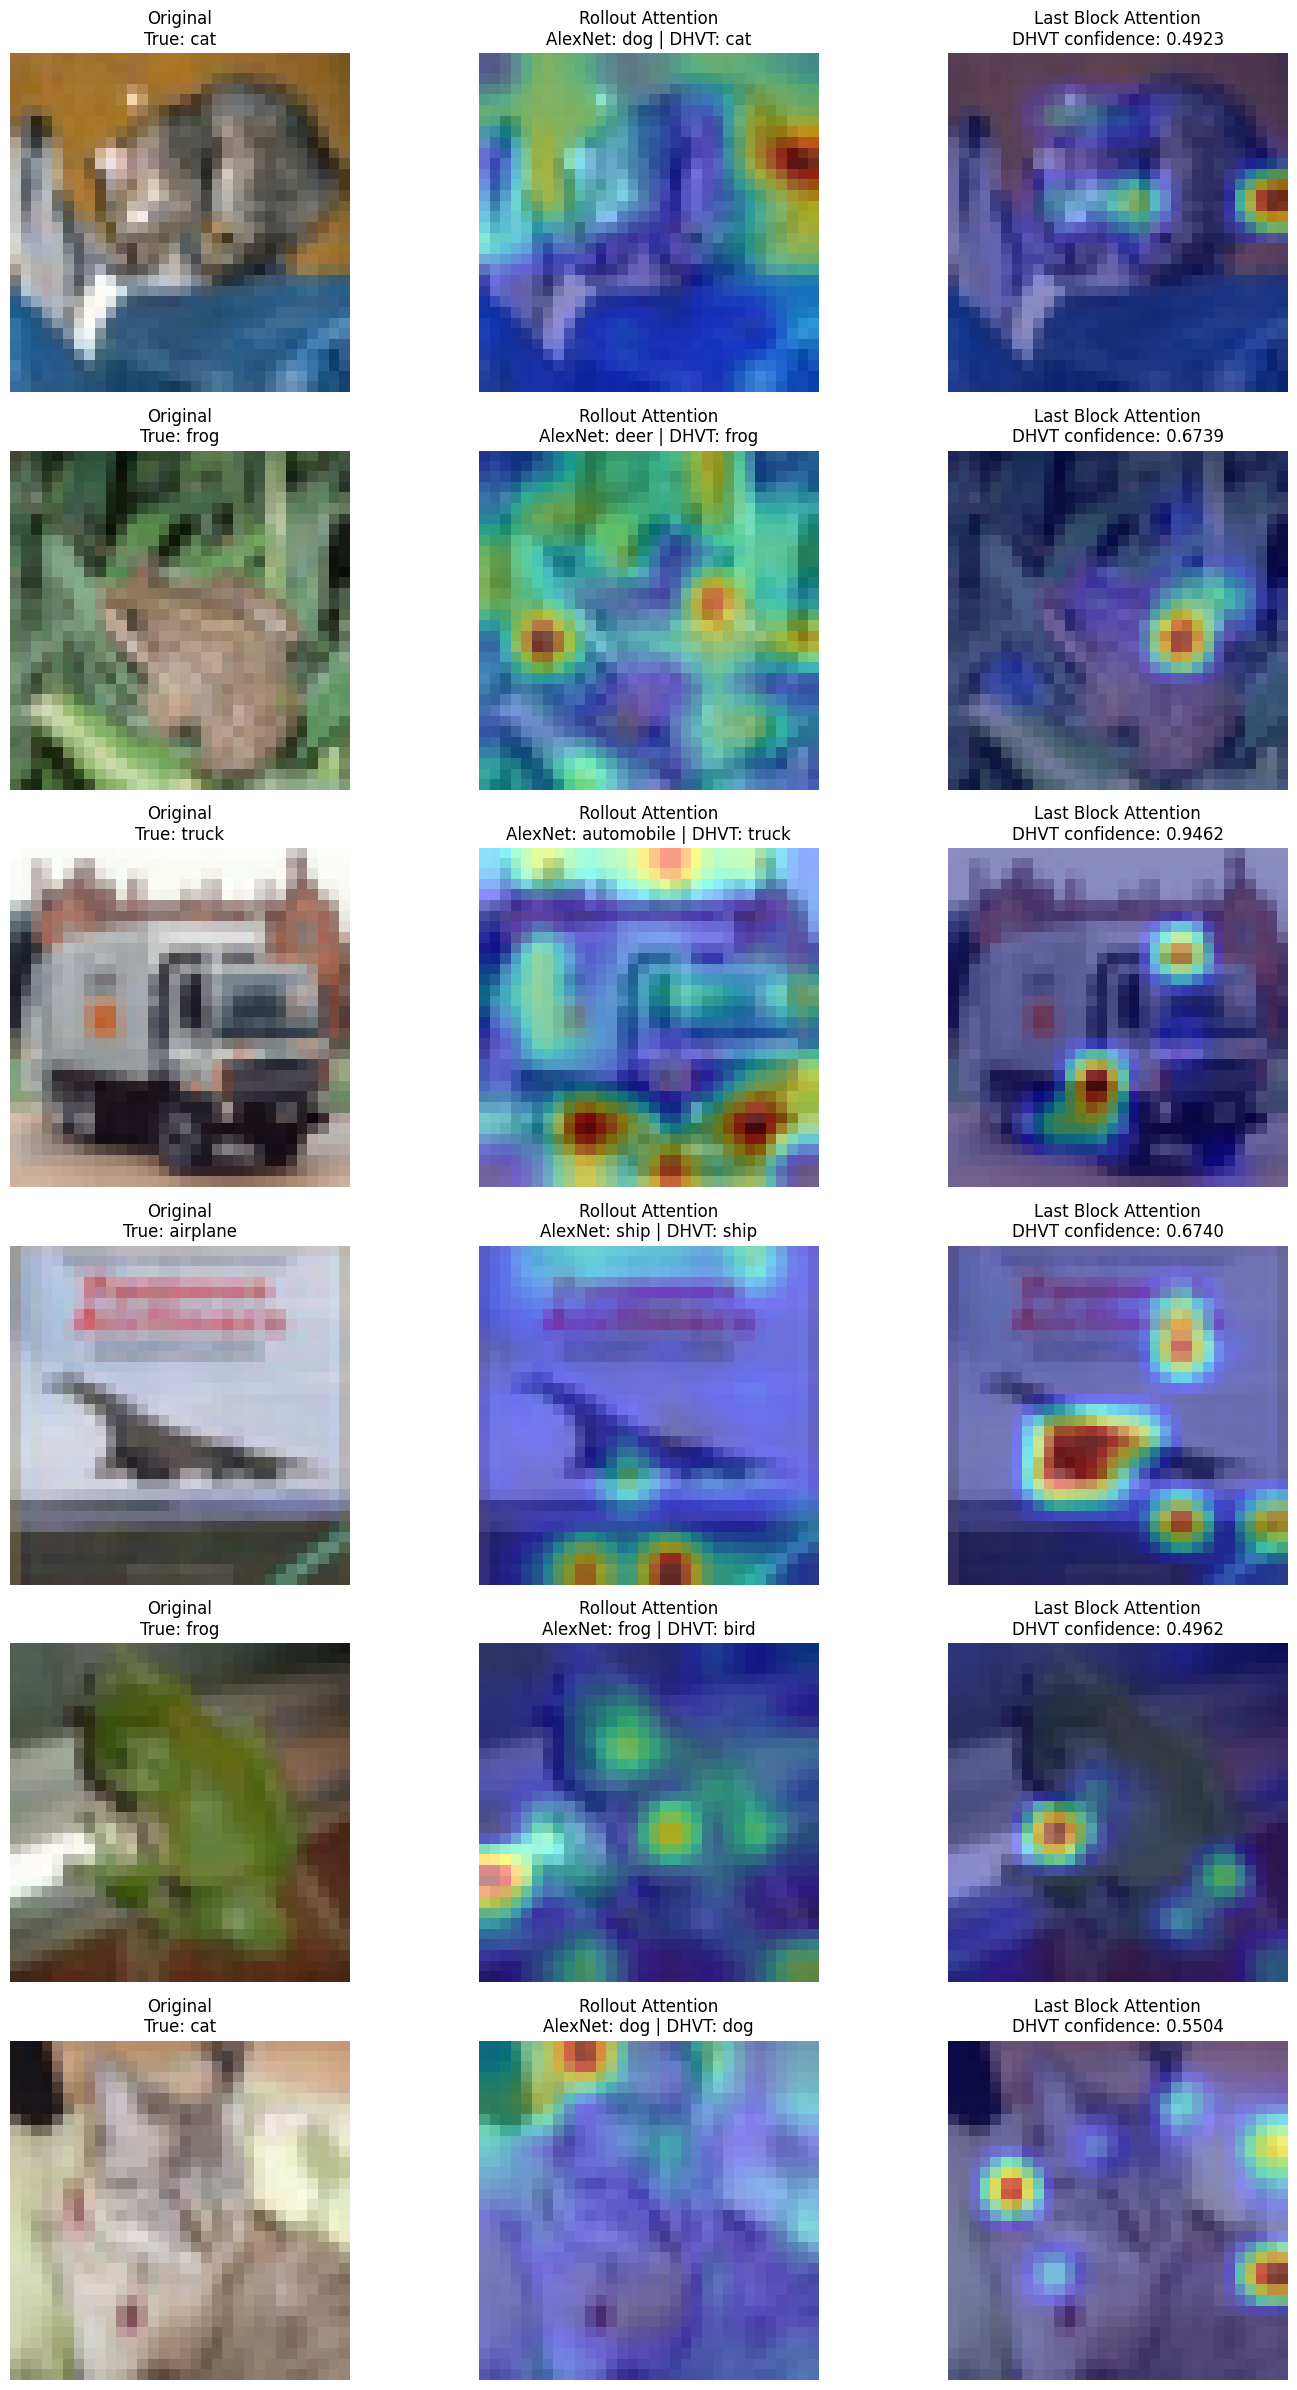

Attention visualization saved in: /content/drive/MyDrive/classification-deep-learning-project/report/figures/08_dhvt_attention_visualization.png
Attention sample count: 6
Attention token count: 65
Attention patch grid size: 8 x 8


In [45]:
attention_visual_dataset = None
if dataset_name == 'cifar10':
    attention_visual_dataset = datasets.CIFAR10(root=str(data_dir), train=False, download=True, transform=transforms.ToTensor())
elif dataset_name == 'cifar100':
    attention_visual_dataset = datasets.CIFAR100(root=str(data_dir), train=False, download=True, transform=transforms.ToTensor())
elif dataset_name == 'custom_folder':
    attention_visual_dataset = datasets.ImageFolder(root=str(custom_dataset_dir / 'val'), transform=transforms.ToTensor())

if attention_visual_dataset is not None:
    dhvt_only_correct_indices = [
        index for index, (true_label, alex_pred, dhvt_pred) in enumerate(zip(labels_all, alexnet_predictions_all, dhvt_predictions_all))
        if alex_pred != true_label and dhvt_pred == true_label
    ]
    dhvt_wrong_indices = [
        index for index, (true_label, dhvt_pred) in enumerate(zip(labels_all, dhvt_predictions_all))
        if dhvt_pred != true_label
    ]

    attention_indices = []
    for index in dhvt_only_correct_indices[:3] + dhvt_wrong_indices[:3]:
        if index not in attention_indices:
            attention_indices.append(index)

    if len(attention_indices) == 0:
        print('No suitable samples were found for DHVT attention visualization.')
    else:
        plt.figure(figsize=(15, 4 * len(attention_indices)))

        for row_index, sample_index in enumerate(attention_indices, start=1):
            image_tensor, _ = attention_visual_dataset[sample_index]
            dhvt_input_tensor, _ = dhvt_testset[sample_index]
            dhvt_input_tensor = dhvt_input_tensor.unsqueeze(0).to(device)

            with torch.inference_mode():
                dhvt_output = dhvt_model(dhvt_input_tensor)
                dhvt_probabilities = torch.softmax(dhvt_output[0], dim=0)
                dhvt_confidence, dhvt_predicted = torch.max(dhvt_probabilities, 0)

            token_count = dhvt_model.blocks[0].attn.last_attn.shape[-1]
            rollout = torch.eye(token_count)
            for block in dhvt_model.blocks:
                block_attention = block.attn.last_attn[0].cpu().mean(dim=0)
                block_attention = block_attention + torch.eye(token_count)
                block_attention = block_attention / block_attention.sum(dim=-1, keepdim=True)
                rollout = block_attention @ rollout

            rollout_map = rollout[0, 1:]
            grid_size = int(rollout_map.numel() ** 0.5)
            rollout_map = rollout_map.reshape(grid_size, grid_size)
            rollout_map = rollout_map / rollout_map.max().clamp(min=1e-8)
            rollout_map = F.interpolate(
                rollout_map.unsqueeze(0).unsqueeze(0),
                size=(image_tensor.shape[1], image_tensor.shape[2]),
                mode='bilinear',
                align_corners=False
            )[0, 0].numpy()

            last_block_attention = dhvt_model.blocks[-1].attn.last_attn[0].cpu()[:, 0, 1:].mean(dim=0)
            last_block_attention = last_block_attention.reshape(grid_size, grid_size)
            last_block_attention = last_block_attention / last_block_attention.max().clamp(min=1e-8)
            last_block_attention = F.interpolate(
                last_block_attention.unsqueeze(0).unsqueeze(0),
                size=(image_tensor.shape[1], image_tensor.shape[2]),
                mode='bilinear',
                align_corners=False
            )[0, 0].numpy()

            image = image_tensor.permute(1, 2, 0).numpy()
            true_label = labels_all[sample_index]
            alex_pred = alexnet_predictions_all[sample_index]
            dhvt_pred = dhvt_predictions_all[sample_index]

            plt.subplot(len(attention_indices), 3, (row_index - 1) * 3 + 1)
            plt.imshow(image)
            plt.axis('off')
            plt.title(f"Original\nTrue: {classes[true_label]}")

            plt.subplot(len(attention_indices), 3, (row_index - 1) * 3 + 2)
            plt.imshow(image)
            plt.imshow(rollout_map, cmap='jet', alpha=0.45)
            plt.axis('off')
            plt.title(
                f"Rollout Attention\nAlexNet: {classes[alex_pred]} | DHVT: {classes[dhvt_pred]}"
            )

            plt.subplot(len(attention_indices), 3, (row_index - 1) * 3 + 3)
            plt.imshow(image)
            plt.imshow(last_block_attention, cmap='jet', alpha=0.45)
            plt.axis('off')
            plt.title(f"Last Block Attention\nDHVT confidence: {dhvt_confidence.item():.4f}")

        plt.tight_layout()
        plt.savefig(report_figure_dir / '08_dhvt_attention_visualization.png', dpi=300, bbox_inches='tight')
        plt.show()

        print('Attention visualization saved in:', report_figure_dir / '08_dhvt_attention_visualization.png')
        print('Attention sample count:', len(attention_indices))
        print('Attention token count:', token_count)
        print('Attention patch grid size:', grid_size, 'x', grid_size)
else:
    print('DHVT attention visualization is prepared for CIFAR and custom_folder evaluation datasets.')


## Results and Discussion

The results in this notebook are discussed from several perspectives rather than from accuracy alone. First, the validation loss and validation accuracy curves show how the two models learn during training. AlexNet usually provides a strong and stable convolutional baseline, while DHVT is expected to capture richer global relationships through transformer-style representations. By comparing the curves, it is possible to judge not only which model performs better, but also which model converges faster and which one behaves more stably across epochs.

Second, the confusion matrices and per-class accuracy plots provide a more detailed comparison of classification behavior. These visualizations help identify whether one model is consistently strong across classes or whether its performance is concentrated on only a few categories. This is important because two models may achieve similar overall accuracy while showing very different error patterns.

Third, the precision, recall, and F1-score plots extend the comparison beyond raw correctness. These class-wise metrics are useful for evaluating whether the predictions are balanced. In particular, F1-score is helpful when discussing whether the model can maintain both good precision and good recall across different categories in the same dataset.

The confidence distribution plots also add another layer of interpretation. They show whether the model tends to make confident predictions and whether incorrect predictions are still assigned high confidence. If a model is frequently wrong with high confidence, then its predictions are less trustworthy in practice even when its accuracy is acceptable.

Finally, the misclassified examples and the images misclassified by both models are useful for qualitative analysis. These cases reveal the limitations of both AlexNet and DHVT. In some samples, one model may succeed while the other fails, which suggests that the two architectures learn different visual cues. In other samples, both models fail, which may indicate that the image itself is ambiguous, the object appearance is unusual, or the dataset classes are visually similar. These observations are valuable for explaining the strengths and weaknesses of convolution-based and transformer-based approaches on the same dataset.

Overall, this comparison is not only about selecting a model with a higher score. It is also about understanding how the two model families behave, what kinds of errors they make, and whether the modified transformer model provides meaningful advantages over the classical CNN baseline.

## Conclusion

In this notebook, I compared AlexNet and DHVT on the same image classification dataset under a shared experimental setting. This design makes the comparison fairer because both models use the same training data, validation data, and custom test images.

AlexNet serves as a classical convolutional baseline, while DHVT represents a transformer-inspired model designed for small datasets. By placing the two models in one notebook, it becomes easier to compare their learning curves, prediction confidence, class-level performance, and failure cases in a direct and consistent way.

The main value of this experiment is not only to report which model performs better, but also to show how different neural network architectures respond to the same task. If DHVT achieves better results, this supports the idea that transformer-based designs can be competitive even on relatively small datasets when the structure is adapted carefully. If AlexNet remains competitive or stronger, then the experiment also confirms the continued importance of convolutional inductive bias in image classification.

In conclusion, this notebook provides a complete homework-style comparison between a CNN baseline and a transformer-style model. It includes training, model saving, loading, inference, visual evaluation, and error analysis, which together form a clear foundation for further discussion in the written report.

## References

1. Krizhevsky, Sutskever, and Hinton. *ImageNet Classification with Deep Convolutional Neural Networks*. 2012.
2. Lu et al. *Bridging the Gap Between Vision Transformers and Convolutional Neural Networks on Small Datasets*. 2022.
3. PyTorch Documentation. https://pytorch.org/
4. Torchvision Documentation. https://pytorch.org/vision/stable/